# پیش‌بینی ابتلا به دیابت با یادگیری ماشین

این نوت‌بوک شامل:
1. بررسی اولیه داده‌ها و شاخص های آماری
2. ترسیم نمودار هیستوگرام ویژگی ها
3. پیش‌پردازش و جایگزینی مقادیر مفقودی
4. تقسیم داده‌ها
5. استانداردسازی داده ها
6. آموزش مدل Random Forest, Decision Tree, XGBoost, LogisticRegression, SVM
7. ارزیابی با معیارهای مختلف
8. رسم Confusion Matrix
9. تحلیل نتایج
10. ترسیم نمودار ROC
11. Feature Importance Analysis

In [454]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    recall_score,
    roc_curve
)

# بارگذاری داده
df = pd.read_csv('diabetes.csv')

In [455]:
# نمایش 5 سطر اول
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [456]:
df.info() # اطلاعات کلی دیتاست

desc = df.describe() # آمار توصیفی
desc.loc['median'] = df.median(numeric_only=True)
desc

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000
median,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000


C:\Users\ASUS\AppData\Local\Temp\ipykernel_5904\2137680600.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


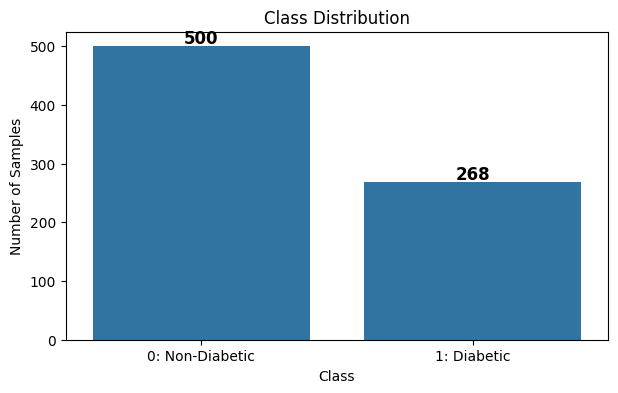

In [457]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the classes
class_counts = df['Outcome'].value_counts().sort_index()

# Class labels
class_names = {
    0: "Non-Diabetic",
    1: "Diabetic"
}

plt.figure(figsize=(7,4))

ax = sns.barplot(
    x=class_counts.index,
    y=class_counts.values
)

# Set x-axis labels
ax.set_xticklabels([
    f"0: Non-Diabetic",
    f"1: Diabetic"
])

# Add counts above each bar
for i, count in enumerate(class_counts.values):
    ax.text(
        i,
        count + 5,              # slightly above the bar
        str(count),
        ha='center',
        fontsize=12,
        fontweight='bold'
    )

plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("Class Distribution")
plt.show()

array([[<Axes: title={'center': 'Pregnancies'}>,
        <Axes: title={'center': 'Glucose'}>,
        <Axes: title={'center': 'BloodPressure'}>],
       [<Axes: title={'center': 'SkinThickness'}>,
        <Axes: title={'center': 'Insulin'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'DiabetesPedigreeFunction'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Outcome'}>]], dtype=object)

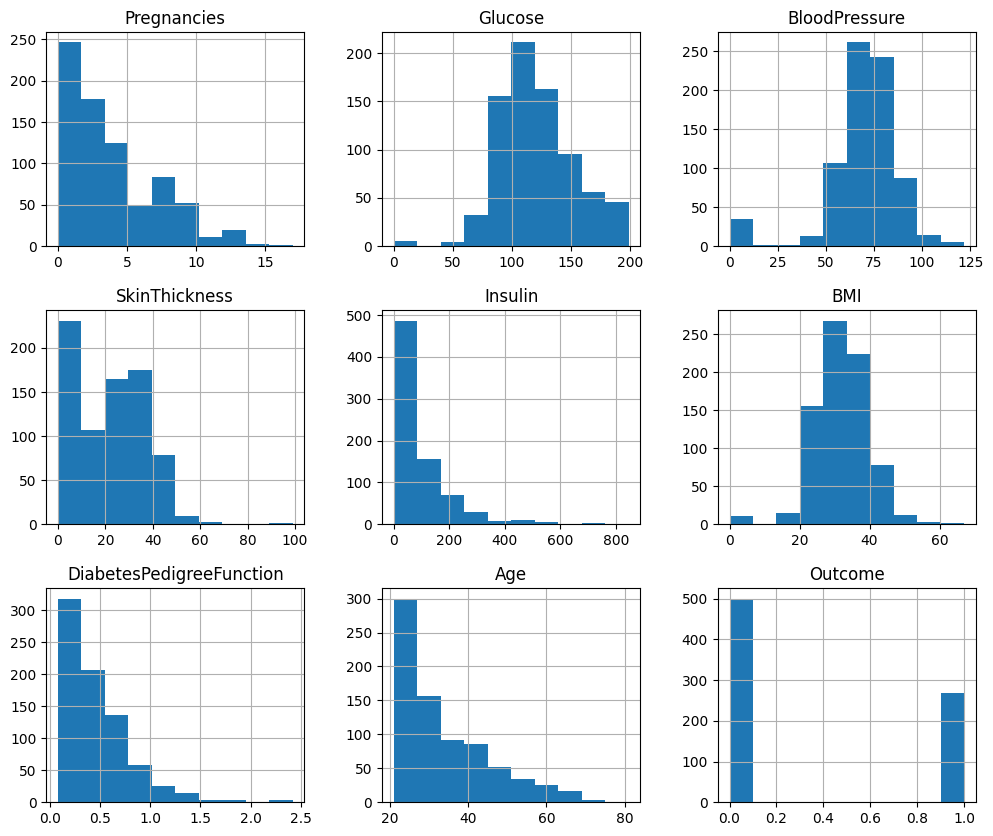

In [458]:
df.hist(figsize=(12,10))

<Axes: >

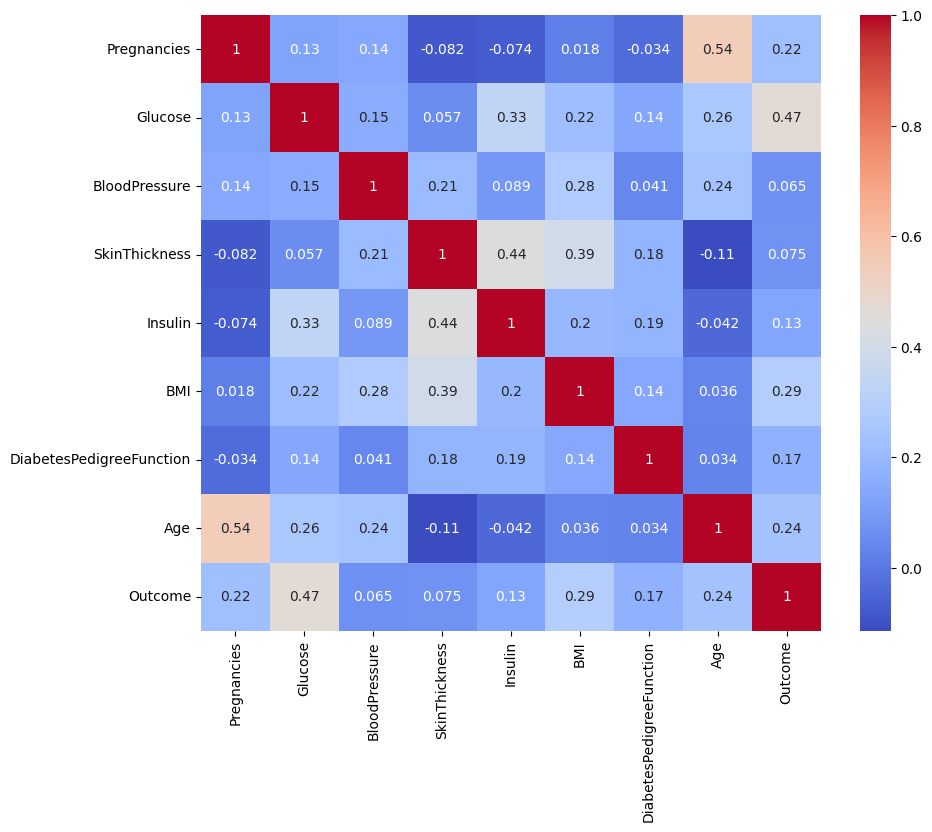

In [459]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

**پیش‌پردازش داده‌ها**

در این دیتاست مقادیر صفر برای ستون‌های زیر غیرمنطقی هستند:

Glucose,
BloodPressure,
SkinThickness,
Insulin,
BMI

جایگزینی با Median:

In [460]:
# بررسی تعداد صفرهای غیرمنطقی به عنوان مقادیر مفقودی
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
for c in cols:
    print(c, (df[c] == 0).sum())

Glucose 5
BloodPressure 35
SkinThickness 227
Insulin 374
BMI 11


In [ ]:
for col in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
    m = df.loc[df[col] != 0, col].median()
    df.loc[df[col] == 0, col] = m # Replacing missing values with median
    print(col, ':', df[col].eq(0).sum())

Glucose : 0
BloodPressure : 0
SkinThickness : 0
Insulin : 0
BMI : 0


In [ ]:
# تفکیک ویژگی‌ها و برچسب

X = df.drop('Outcome', axis=1)
y = df['Outcome']
# deviding dataset to train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)


(614, 8)
(154, 8)


**استانداردسازی داده‌ها**

In [ ]:
# Normalization of features
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**آموزش چند مدل مختلف**

In [464]:
results = [] # save results in a list
roc_results = {}

In [465]:
from sklearn.linear_model import LogisticRegression

model_LR = LogisticRegression(max_iter=50)
model_LR.fit(X_train_scaled, y_train)

y_pred_LR = model_LR.predict(X_test_scaled)
y_prob_LR = model_LR.predict_proba(X_test_scaled)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob_LR)
auc = roc_auc_score(y_test, y_prob_LR)

roc_results['Logistic Regression'] = {
    'fpr': fpr,
    'tpr': tpr,
    'auc': auc
}

In [466]:
# محاسبه معیارهای ارزیابی

acc = accuracy_score(y_test, y_pred_LR)
f1 = f1_score(y_test, y_pred_LR)

cm = confusion_matrix(y_test, y_pred_LR)

TN, FP, FN, TP = cm.ravel()

sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)

roc_auc = roc_auc_score(y_test, y_prob_LR)

results.append({
    'Model': 'Logistic Regression',
    'Accuracy': acc,
    'F1-Score': f1,
    'Sensitivity': sensitivity,
    'Specificity': specificity,
    'ROC-AUC': roc_auc
})

print(f'Accuracy   : {acc:.4f}')
print(f'F1-Score   : {f1:.4f}')
print(f'Sensitivity: {sensitivity:.4f}')
print(f'Specificity: {specificity:.4f}')
print(f'ROC-AUC    : {roc_auc:.4f}')

Accuracy   : 0.7078
F1-Score   : 0.5455
Sensitivity: 0.5000
Specificity: 0.8200
ROC-AUC    : 0.8130


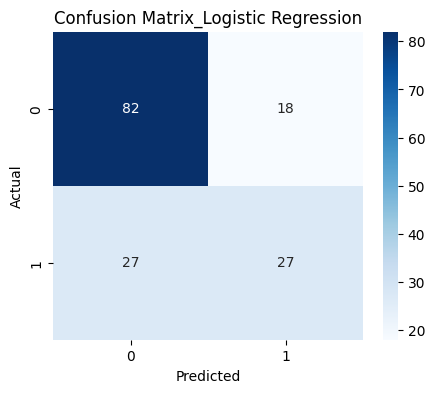

In [467]:
# رسم Confusion Matrix

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix_Logistic Regression')
plt.show()

In [468]:
from sklearn.tree import DecisionTreeClassifier
model_dt = DecisionTreeClassifier(max_depth=4)
model_dt.fit(X_train_scaled, y_train)

y_pred_dt = model_dt.predict(X_test_scaled)
y_prob_dt = model_dt.predict_proba(X_test_scaled)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob_dt)
auc = roc_auc_score(y_test, y_prob_dt)

roc_results['Decision Tree'] = {
    'fpr': fpr,
    'tpr': tpr,
    'auc': auc
}

In [469]:
# محاسبه معیارهای ارزیابی

acc = accuracy_score(y_test, y_pred_dt)
f1 = f1_score(y_test, y_pred_dt)

cm = confusion_matrix(y_test, y_pred_dt)

TN, FP, FN, TP = cm.ravel()

sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)

roc_auc = roc_auc_score(y_test, y_prob_dt)

results.append({
    'Model': 'Decision Tree',
    'Accuracy': acc,
    'F1-Score': f1,
    'Sensitivity': sensitivity,
    'Specificity': specificity,
    'ROC-AUC': roc_auc
})

print(f'Accuracy   : {acc:.4f}')
print(f'F1-Score   : {f1:.4f}')
print(f'Sensitivity: {sensitivity:.4f}')
print(f'Specificity: {specificity:.4f}')
print(f'ROC-AUC    : {roc_auc:.4f}')

Accuracy   : 0.7857
F1-Score   : 0.6916
Sensitivity: 0.6852
Specificity: 0.8400
ROC-AUC    : 0.7887


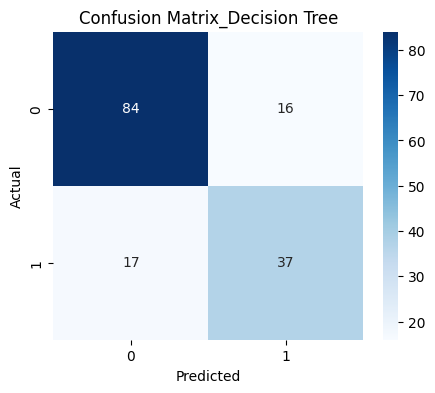

In [470]:
# رسم Confusion Matrix

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix_Decision Tree')
plt.show()

In [471]:
from sklearn.ensemble import RandomForestClassifier
model_RF = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=42
)

model_RF.fit(X_train_scaled, y_train)

y_pred_RF = model_RF.predict(X_test_scaled)
y_prob_RF = model_RF.predict_proba(X_test_scaled)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob_RF)
auc = roc_auc_score(y_test, y_prob_RF)

roc_results['Random Forest'] = {
    'fpr': fpr,
    'tpr': tpr,
    'auc': auc
}

In [472]:
# محاسبه معیارهای ارزیابی

acc = accuracy_score(y_test, y_pred_RF)
f1 = f1_score(y_test, y_pred_RF)

cm = confusion_matrix(y_test, y_pred_RF)

TN, FP, FN, TP = cm.ravel()

sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)

roc_auc = roc_auc_score(y_test, y_prob_RF)

results.append({
    'Model': 'Random Forest',
    'Accuracy': acc,
    'F1-Score': f1,
    'Sensitivity': sensitivity,
    'Specificity': specificity,
    'ROC-AUC': roc_auc
})

print(f'Accuracy   : {acc:.4f}')
print(f'F1-Score   : {f1:.4f}')
print(f'Sensitivity: {sensitivity:.4f}')
print(f'Specificity: {specificity:.4f}')
print(f'ROC-AUC    : {roc_auc:.4f}')

Accuracy   : 0.7597
F1-Score   : 0.6263
Sensitivity: 0.5741
Specificity: 0.8600
ROC-AUC    : 0.8142


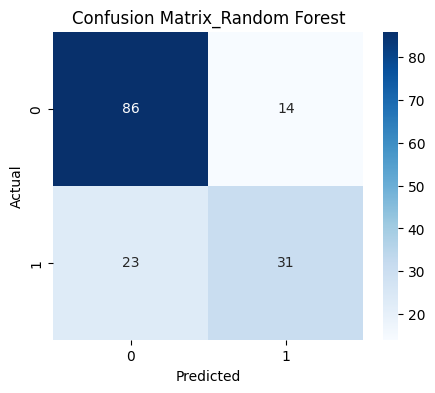

In [473]:
# رسم Confusion Matrix

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix_Random Forest')
plt.show()


In [ ]:
from xgboost import XGBClassifier

model_xg = XGBClassifier(
    n_estimators=300,
    learning_rate=0.01,
    max_depth=8
)
# model_xg = XGBClassifier(eval_metric='logloss',use_label_encoder=False, n_estimators=500,learning_rate=0.01,subsample=1,max_depth=9)

model_xg.fit(X_train_scaled, y_train)

y_pred_xg = model_xg.predict(X_test_scaled)
y_prob_xg = model_xg.predict_proba(X_test_scaled)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob_xg)
auc = roc_auc_score(y_test, y_prob_xg)

roc_results['xgboost'] = {
    'fpr': fpr,
    'tpr': tpr,
    'auc': auc
}

In [475]:
# محاسبه معیارهای ارزیابی

acc = accuracy_score(y_test, y_pred_xg)
f1 = f1_score(y_test, y_pred_xg)

cm = confusion_matrix(y_test, y_pred_xg)

TN, FP, FN, TP = cm.ravel()

sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)

roc_auc = roc_auc_score(y_test, y_prob_xg)

results.append({
    'Model': 'XGBoost',
    'Accuracy': acc,
    'F1-Score': f1,
    'Sensitivity': sensitivity,
    'Specificity': specificity,
    'ROC-AUC': roc_auc
})

print(f'Accuracy   : {acc:.4f}')
print(f'F1-Score   : {f1:.4f}')
print(f'Sensitivity: {sensitivity:.4f}')
print(f'Specificity: {specificity:.4f}')
print(f'ROC-AUC    : {roc_auc:.4f}')

Accuracy   : 0.7727
F1-Score   : 0.6392
Sensitivity: 0.5741
Specificity: 0.8800
ROC-AUC    : 0.8246


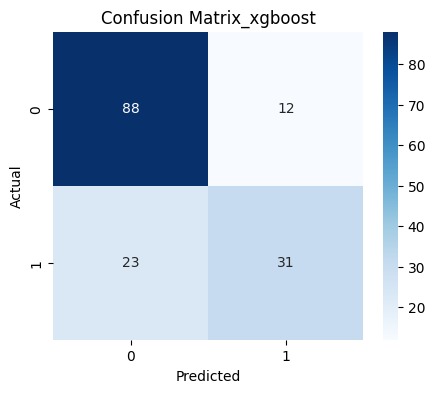

In [476]:
# رسم Confusion Matrix

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix_xgboost')
plt.show()


In [477]:
from sklearn.svm import SVC
model_svm = SVC(
    kernel='rbf',
    probability=True
)

model_svm.fit(X_train_scaled, y_train)

y_pred_svm = model_svm.predict(X_test_scaled)
y_prob_svm = model_svm.predict_proba(X_test_scaled)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob_svm)
auc = roc_auc_score(y_test, y_prob_svm)

roc_results['SVM'] = {
    'fpr': fpr,
    'tpr': tpr,
    'auc': auc
}

In [478]:
# محاسبه معیارهای ارزیابی

acc = accuracy_score(y_test, y_pred_svm)
f1 = f1_score(y_test, y_pred_svm)

cm = confusion_matrix(y_test, y_pred_svm)

TN, FP, FN, TP = cm.ravel()

sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)

roc_auc = roc_auc_score(y_test, y_prob_svm)

results.append({
    'Model': 'SVM',
    'Accuracy': acc,
    'F1-Score': f1,
    'Sensitivity': sensitivity,
    'Specificity': specificity,
    'ROC-AUC': roc_auc
})

print(f'Accuracy   : {acc:.4f}')
print(f'F1-Score   : {f1:.4f}')
print(f'Sensitivity: {sensitivity:.4f}')
print(f'Specificity: {specificity:.4f}')
print(f'ROC-AUC    : {roc_auc:.4f}')

Accuracy   : 0.7403
F1-Score   : 0.6000
Sensitivity: 0.5556
Specificity: 0.8400
ROC-AUC    : 0.7964


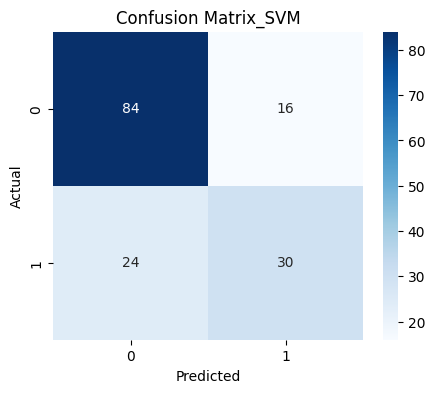

In [479]:
# رسم Confusion Matrix

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix_SVM')
plt.show()


In [480]:
results_df = pd.DataFrame(results) # Converting the list to dataframe
# Sorting the classifiers based on one criteria
results_df = results_df.sort_values(
    by='Accuracy',
    ascending=False
)

results_df.reset_index(drop=True, inplace=True)

print(results_df)

                 Model  Accuracy  F1-Score  Sensitivity  Specificity   ROC-AUC
0        Decision Tree  0.785714  0.691589     0.685185         0.84  0.788704
1              XGBoost  0.772727  0.639175     0.574074         0.88  0.824630
2        Random Forest  0.759740  0.626263     0.574074         0.86  0.814167
3                  SVM  0.740260  0.600000     0.555556         0.84  0.796389
4  Logistic Regression  0.707792  0.545455     0.500000         0.82  0.812963


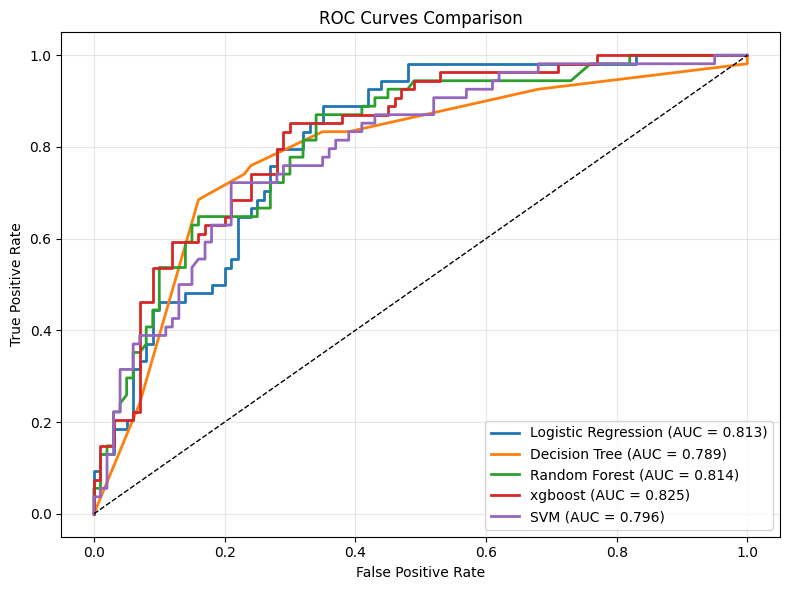

In [481]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for model_name, result in roc_results.items():
    plt.plot(
        result['fpr'],
        result['tpr'],
        linewidth=2,
        label=f"{model_name} (AUC = {result['auc']:.3f})"
    )

# Random classifier
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')

plt.legend(loc='lower right')

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Analysis of Model Performance

Five machine learning models were evaluated for predicting diabetes using Accuracy, F1-Score, Sensitivity, Specificity, and ROC-AUC. All models achieved an accuracy above the project requirement of 70%, indicating that they are suitable for this classification task.

Among the evaluated models, the **Decision Tree** demonstrated the best overall performance. It achieved the highest **Accuracy (78.57%)**, **F1-Score (0.692)**, and **Sensitivity (68.52%)**, while maintaining a high **Specificity (84%)** and a competitive **ROC-AUC (0.789)**. Its superior sensitivity indicates that it correctly identified the largest proportion of diabetic patients, which is particularly important in medical diagnosis where missing positive cases can have serious consequences.

Although **XGBoost** produced the highest **ROC-AUC (0.825)**, suggesting the best ability to distinguish between diabetic and non-diabetic patients across different classification thresholds, its sensitivity (57.41%) was considerably lower than that of the Decision Tree. This indicates that XGBoost was more conservative in predicting positive cases, leading to more missed diabetic patients.

**Random Forest** achieved performance similar to XGBoost but with slightly lower accuracy and ROC-AUC. **SVM** produced moderate results, while **Logistic Regression** showed the weakest performance, with the lowest accuracy, F1-score, and sensitivity. This suggests that the relationship between the input features and diabetes status is likely non-linear, making tree-based methods more suitable than a linear classifier.

Overall, the results indicate that **tree-based models outperform linear models on the Pima Indians Diabetes dataset**. Considering the balance between overall accuracy and the ability to correctly detect diabetic patients, the **Decision Tree** can be considered the most appropriate model for this dataset. However, if maximizing discrimination across thresholds is the primary objective, **XGBoost** would be a strong alternative due to its superior ROC-AUC.


**Feature Importance With Random Forest**

<Axes: xlabel='Importance', ylabel='Feature'>

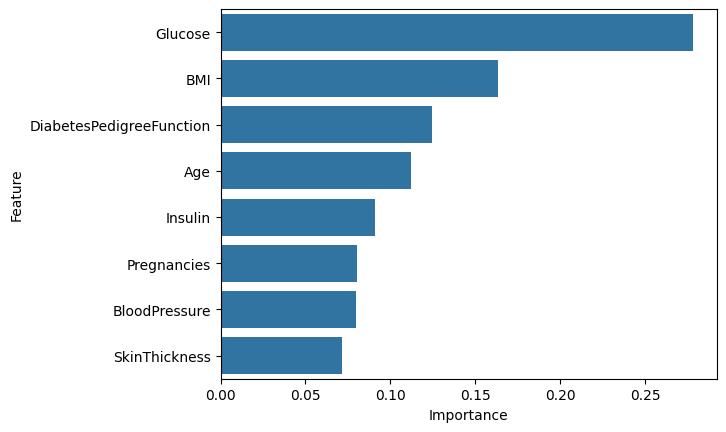

In [482]:
# Extracting Importance of Features
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model_RF.feature_importances_
})
# Sorting Important features
importance = importance.sort_values(by='Importance',
    ascending=False
)
sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)